# AI Financial Analytics & Investment Insight Platform

This notebook demonstrates:
- Stock data analysis
- Feature engineering
- Machine learning prediction
- Portfolio optimization
- AI-powered financial insights

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import yfinance as yf

from data_loader import load_stock_data
from features import add_features
from model import train_model
from portfolio import optimize_portfolio

In [2]:
import yfinance as yf
import pandas as pd

data = yf.download("AAPL", start="2019-01-01")
data = data[['Close', 'Volume']]
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data.dropna(inplace=True)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,Volume
Date,,
2019-01-02,37.503727,148158800
2019-01-03,33.768078,365248800
2019-01-04,35.209610,234428400
2019-01-07,35.131245,219111200
2019-01-08,35.800945,164101200


In [3]:
# ticker = input("Enter stock ticker (AAPL, TSLA, MSFT): ").upper()
ticker = 'AAPL'

print("Selected:", ticker)

Selected: AAPL


In [4]:
# data = load_stock_data(ticker)
# data = yf.download(ticker)["Close"]
# data.head()

In [5]:
data.describe()

Price,Close,Volume
count,1811.000000,1.811000e+03
mean,151.540327,8.735072e+07
std,63.203062,5.098437e+07
min,33.768078,1.017939e+07
25%,113.513805,5.220140e+07
50%,152.061539,7.477040e+07
75%,192.693207,1.055430e+08
max,285.922455,4.265100e+08


In [6]:
data.isnull().sum()

Price
Close     0
Volume    0
dtype: int64

In [7]:
fig = px.line(
    data,
    x=data.index,
    y=data.columns,
    title=f"{ticker} Stock Price",
)

# Improve layout
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_dark"
)

fig.show()

In [8]:
data = add_features(data)

data.head()

Price,Close,Volume,MA50,MA200,Return,Volatility,Target
Date,,,,,,,
2019-10-16,56.326679,73903200,51.942472,46.344915,-0.004037,0.013968,1
2019-10-17,56.545372,67585200,52.120285,46.440123,0.003883,0.013737,1
2019-10-18,56.816948,97433600,52.282509,46.555368,0.004803,0.013080,1
2019-10-21,57.802315,87247200,52.472468,46.668331,0.017343,0.013406,0
2019-10-22,57.670135,82293600,52.662235,46.781026,-0.002287,0.013324,1


In [9]:
model,accuracy, cv_score = train_model(data)

print("Model Accuracy:", accuracy)
print("CV Score:", cv_score)

c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [22:17:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [22:17:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [22:17:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [22:17:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_labe

Model Accuracy: 0.5108359133126935
CV Score: 0.4738317757009346


[*********************100%***********************]  5 of 5 completed
C:\Users\agamb\AppData\Local\Temp\ipykernel_30348\2968995650.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = price_data.pct_change().dropna()
C:\Users\agamb\AppData\Local\Temp\ipykernel_30348\2968995650.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(risk[i], mean_returns[i], stocks[i])


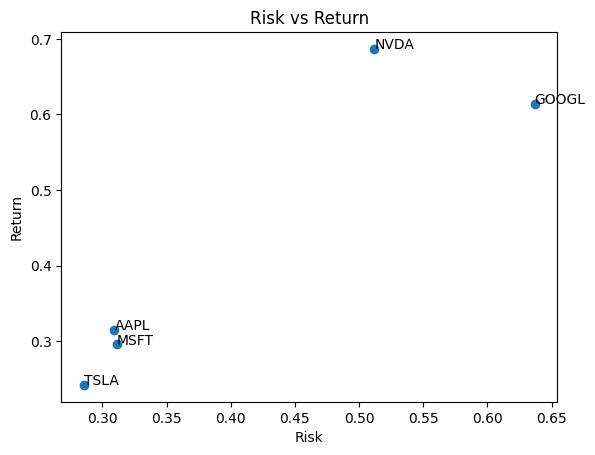

In [10]:
import yfinance as yf
stocks = ["AAPL","MSFT","TSLA","NVDA","GOOGL"]

price_data = yf.download(stocks, start="2019-01-01")["Close"]

returns = price_data.pct_change().dropna()

mean_returns = returns.mean() * 252
risk = returns.std() * (252 ** 0.5)

plt.scatter(risk, mean_returns)

for i in range(len(stocks)):
    plt.text(risk[i], mean_returns[i], stocks[i])

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Risk vs Return")

plt.show()

In [11]:
portfolio, p_return, p_risk = optimize_portfolio(stocks)

portfolio
print("Portfolio Return:", p_return)
print("Portfolio Risk:", p_risk)

[*********************100%***********************]  5 of 5 completed

Portfolio Return: 0.4264492041823335
Portfolio Risk: 0.32417559725554734



c:\Users\agamb\Desktop\Fin AI\src\portfolio.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()
